In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [54]:
def load_img():
    blank_img=np.zeros((600,600))
    font=cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(blank_img,text='ABCDE',org=(50,300), fontFace=font,fontScale=5,color=(255,255,255),thickness=25,lineType=cv2.LINE_AA)
    return blank_img

In [55]:
def display_img(img):
    fig=plt.figure(figsize=(12,10))
    ax=fig.add_subplot(111)
    ax.imshow(img,cmap='gray')
    plt.show()

In [56]:
img=load_img()

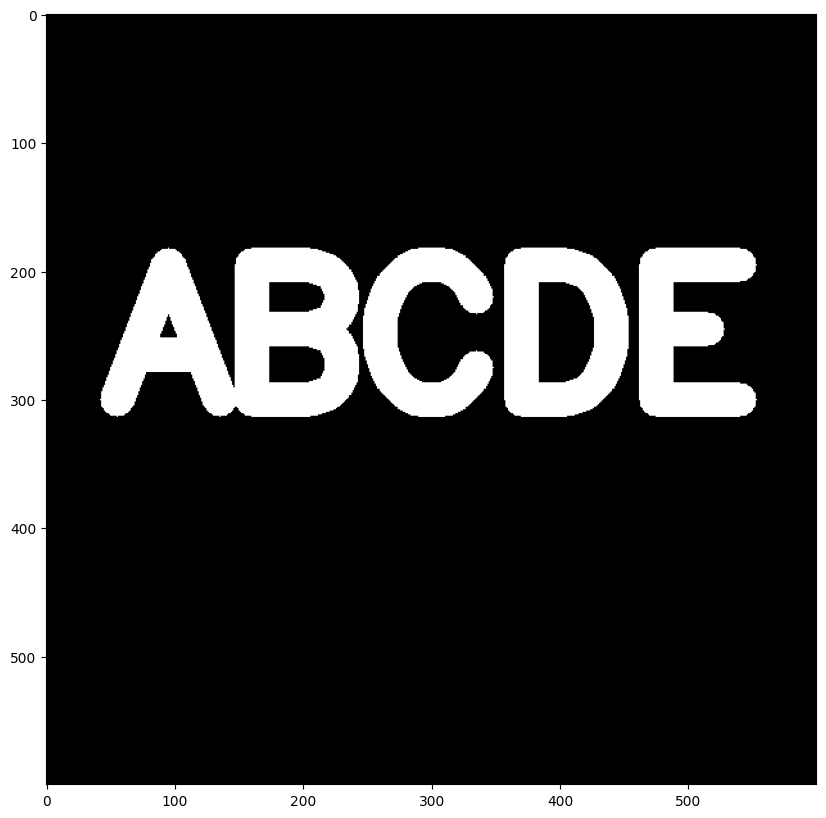

In [57]:
display_img(img)

In [58]:
kernel=np.ones((5,5),dtype=np.uint8)

In [59]:
kernel

array([[1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1]], dtype=uint8)

In [60]:
erosion1=cv2.erode(img,kernel,iterations=4)

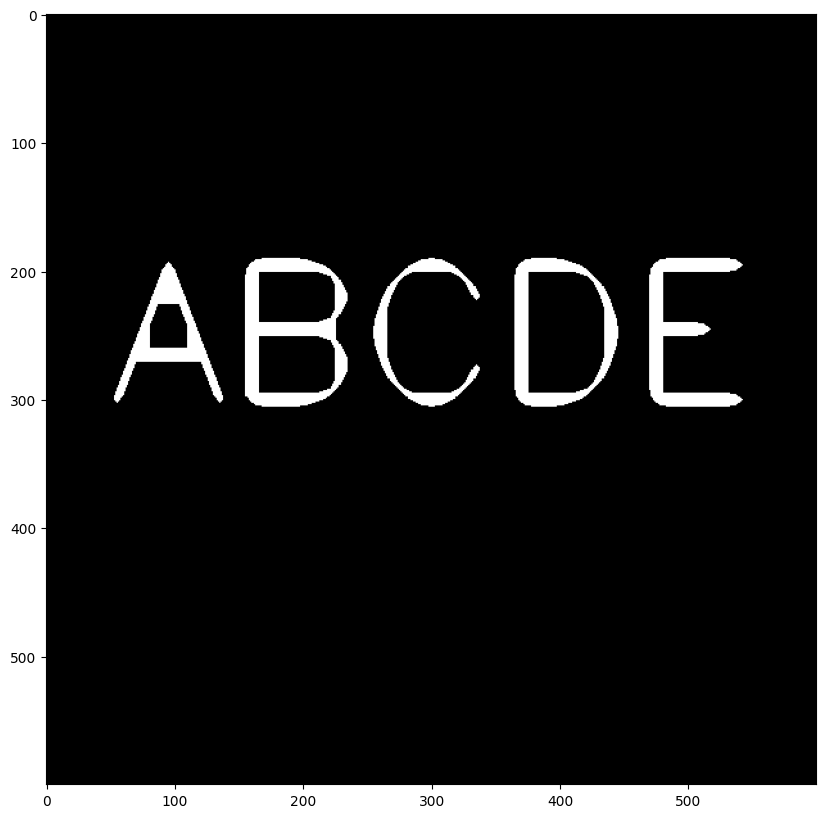

In [61]:
display_img(erosion1)

In [62]:
dilu=cv2.dilate(img,kernel,iterations=4)

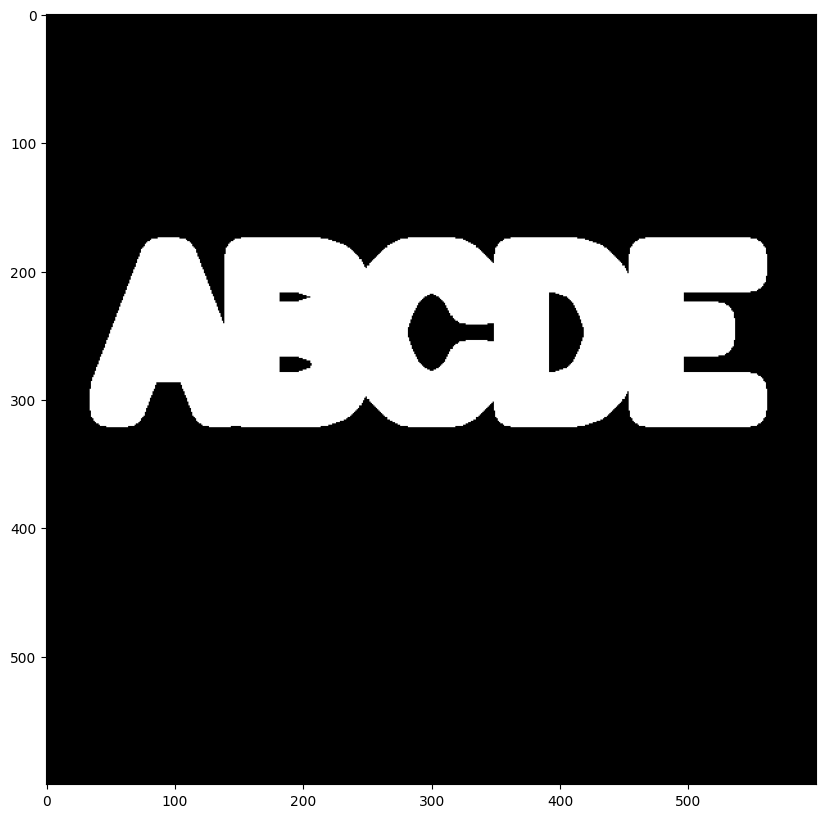

In [63]:
display_img(dilu)

In [64]:
white_noise=np.random.randint(low=0,high=2,size=(600,600))

In [65]:
white_noise

array([[1, 0, 1, ..., 0, 1, 1],
       [0, 1, 1, ..., 1, 0, 1],
       [0, 1, 1, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 1, ..., 0, 0, 1],
       [0, 0, 1, ..., 1, 0, 1]], shape=(600, 600), dtype=int32)

In [66]:
img.max()

np.float64(255.0)

In [67]:
white_noise.max()

np.int32(1)

In [68]:
white_noise=white_noise*255

In [69]:
white_noise.shape

(600, 600)

In [70]:
white_noise

array([[255,   0, 255, ...,   0, 255, 255],
       [  0, 255, 255, ..., 255,   0, 255],
       [  0, 255, 255, ..., 255, 255, 255],
       ...,
       [  0,   0,   0, ...,   0,   0, 255],
       [  0,   0, 255, ...,   0,   0, 255],
       [  0,   0, 255, ..., 255,   0, 255]], shape=(600, 600), dtype=int32)

In [71]:
noise_img = white_noise+img

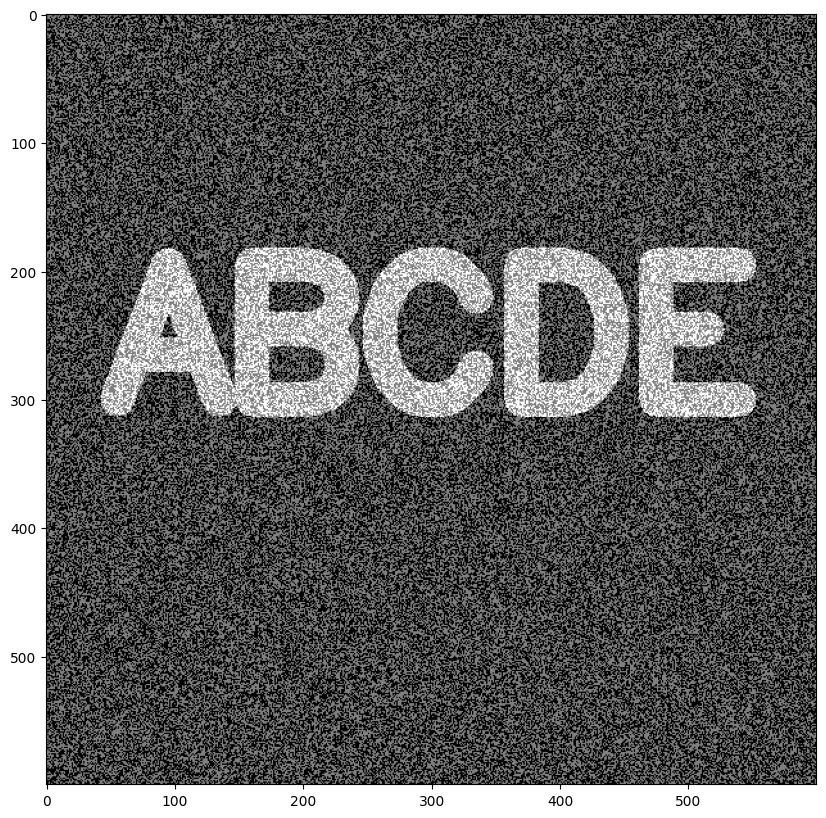

In [72]:
display_img(noise_img)

In [73]:
opening=cv2.morphologyEx(noise_img, cv2.MORPH_OPEN, kernel)

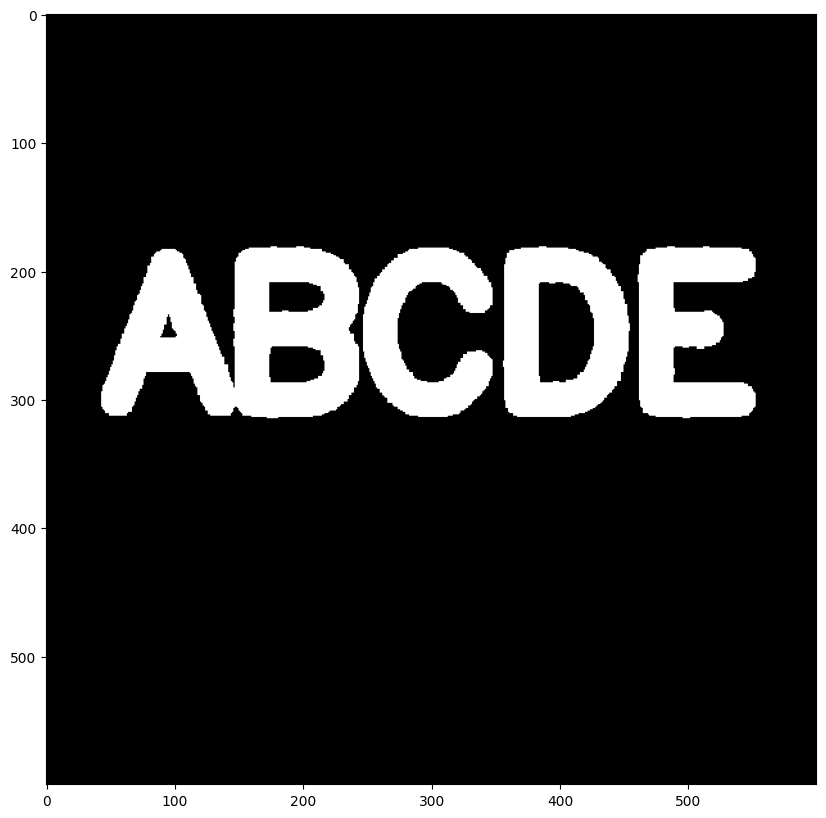

In [75]:
display_img(opening)

In [76]:
img=load_img()

In [77]:
black_noise=np.random.randint(low=0,high=2,size=(600,600))

In [78]:
black_noise

array([[0, 1, 1, ..., 0, 0, 1],
       [0, 0, 1, ..., 0, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       ...,
       [1, 0, 1, ..., 1, 1, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 1, 1, ..., 1, 0, 0]], shape=(600, 600), dtype=int32)

In [79]:
black_noise=black_noise* -255

In [80]:
black_noise_img=img + black_noise

In [82]:
black_noise

array([[   0, -255, -255, ...,    0,    0, -255],
       [   0,    0, -255, ...,    0, -255, -255],
       [   0,    0,    0, ..., -255, -255, -255],
       ...,
       [-255,    0, -255, ..., -255, -255,    0],
       [   0,    0,    0, ...,    0,    0,    0],
       [   0, -255, -255, ..., -255,    0,    0]],
      shape=(600, 600), dtype=int32)

In [83]:
black_noise_img[black_noise_img==-255] = 0

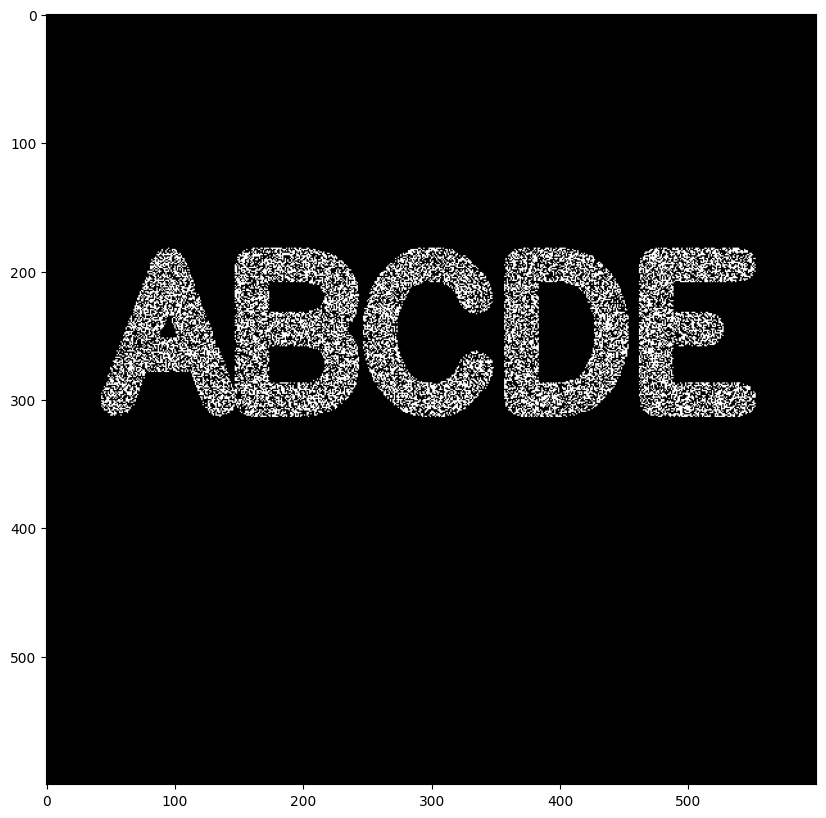

In [84]:
display_img(black_noise_img)